## ⛽ PROJETO - Análise Preditiva e Logística de Vendas de Combustíveis (Petrobras / ANP)

Este estudo aplica **Machine Learning** para classificar padrões de consumo de combustíveis no Brasil (faixas baixa, média e alta), com base em dados oficiais da ANP (2007–2017).

### **🔹Estratégia de Dados**

Fonte: ANP – Dados Abertos
Movimentação de derivados de petróleo

Arquivo: Combustíveis líquidos
Escolher o link Dados abertos (.zip) (atualizado em 03/09/2026)

Link direto para download: **https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/mdpg/liquidos.zip** - (Pasta zipada , o arquivo é *Liquidos_Vendas_Historico_2007_a_2017.csv*  , com **710.832 linhas**).

⚠️ Observação: o arquivo não possui cabeçalho. É necessário incluir manualmente durante o tratamento dos dados.

- **Variáveis-chave:**

> Produto

> Agente regulado

> UF origem/destino

> Mercado destinatário

> Quantidade de vendas

- **Amostragem e Pré-processamento:**  
A amostragem foi estratificada para viabilizar algoritmos intensivos (como GridSearchCV e SMOTE), reduzindo a base para 100.000 registros (2007–2016).

- Essa estratégia preserva:

> Variabilidade temporal

> Representatividade estatística

> Distribuição real das classes

➡️ A redução equilibra custo computacional e tempo de execução, sem comprometer a qualidade analítica.

### **🎯 Objetivos**

Desempenho Preditivo: comparar Random Forest e XGBoost em cenários desbalanceados.

Eficiência Operacional: avaliar o melhor trade-off entre desempenho, tempo de treinamento e consumo de recursos.

### **🚀 Metodologia**
- Preparação de dados (limpeza, engenharia de variáveis, categorização).

- Modelagem com Random Forest e XGBoost, avaliando acurácia, precisão, recall e F1-Score ponderado.

- Evolução dos modelos com SMOTE e otimização de hiperparâmetros.

- Análise crítica de eficiência computacional.

- Consolidação dos resultados em gráficos, tabelas comparativas e relatórios executivos.

In [1]:
# Bibliotecas e Imports

# Ignorar avisos desnecessários
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Manipulação e tratamento de dados
import numpy as np
import pandas as pd

# Visualização
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Utilidades
from unidecode import unidecode
import category_encoders as ce
import time
import joblib

# Scikit-Learn: Pré-processamento e Validação
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-Learn: Métricas de Avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

# Modelos de Machine Learning
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, LinearSVC, SVR
import xgboost as xgb
import lightgbm as lgb

# Balanceamento de Dados
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [2]:
# Carregar base de dados - Arquivo Original - (verificar separador correto: sep=";"  ou sep="," 
df_vendas_hist = pd.read_csv("Liquidos_Vendas_Historico_2007_a_2017.csv", sep=";", encoding="ISO-8859-1")

# Visualizar os primeiros registros
print(df_vendas_hist.head(3))

# Exibir a lista com os nomes de todas as colunas
print(df_vendas_hist.columns.tolist())

   2007  1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  810101001  Etanol Hidratado  SE  \
0  2007  1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  810101001  Etanol Hidratado  SE   
1  2007  1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  810101001  Etanol Hidratado  SE   
2  2007  1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  810101001  Etanol Hidratado  SE   

   SP  NI NI.1                         CONSUMIDOR FINAL  1,981765  
0  SP  SE   MG                         CONSUMIDOR FINAL  0,024030  
1  SP  SE   MG  POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA  1,297300  
2  SP  SE   MG       POSTO DE COMBUSTÍVEIS - BANDEIRADO  0,061000  
['2007', '1', 'ABENGOA BIOENERGIA SÃO JOÃO LTDA', '810101001', 'Etanol Hidratado', 'SE', 'SP', 'NI', 'NI.1', 'CONSUMIDOR FINAL', '1,981765']


#### Visto que a base de dados carece de cabeçalho(descrição das colunas), é necessário criá-los.

In [3]:
# 🛠️ Adicionando cabeçalho e nome das colunas à base de dados

# Lista com os nomes das 11 colunas
colunas = [
    "ano",
    "mes",
    "agente_regulado",
    "codigo_produto",
    "nome_produto",
    "regiao_origem",
    "uf_origem",
    "regiao_destino",
    "uf_destino",
    "mercado_destinatario",
    "quant_vendas",
]

# Carregar o arquivo original aplicando o cabeçalho 
df_vendas_hist = pd.read_csv(
    "Liquidos_Vendas_Historico_2007_a_2017.csv",
    sep=";",                # Separador padrão Brasil
    header=None,            # Sem cabeçalho original
    names=colunas,          # Aplicar nomes das colunas
    decimal=",",            # Converter vírgula para ponto decimal
    encoding="ISO-8859-1",  # Compatível com acentuação e caracteres especiais
)

# Visualizar o resultado limpo (primeira linha com cabeçalho)
display(df_vendas_hist.head(1))

# Salvar arquivo com cabeçalho usando ponto e vírgula para compatibilidade nacional 
# Versão 1.0 — Tratamento inicial da base ANP
df_vendas_hist.to_csv("vendas_2007_a_2017_tratado1.csv", index=False, sep=";")

# Mensagens de confirmação
print("Cabeçalho criado com sucesso!")
print("Etapa 1 concluída: Arquivo salvo como 'vendas_2007_a_2017_tratado1.csv")


,ano,mes,agente_regulado,codigo_produto,nome_produto,regiao_origem,uf_origem,regiao_destino,uf_destino,mercado_destinatario,quant_vendas
0,2007,1,ABENGOA BIOENERGIA SÃO JOÃO LTDA,810101001,Etanol Hidratado,SE,SP,NI,NI,CONSUMIDOR FINAL,1.981765


Cabeçalho criado com sucesso!
Etapa 1 concluída: Arquivo salvo como 'vendas_2007_a_2017_tratado1.csv


## 🛠️ Pré-processamento 

**Etapas Realizadas**
- Inclusão de cabeçalho  
  Foram definidos os nomes das 11 colunas:  
  ano, mes, agente_regulado, codigo_produto, nome_produto,  
  regiao_origem, uf_origem, regiao_destino, uf_destino,  
  mercado_destinatario, quant_vendas.  

- Carregamento do arquivo original  
  - Separador: `;` (ponto e vírgula, padrão Brasil)  
  - Encoding: `ISO-8859-1` (compatível com acentos e caracteres especiais)  
  - Decimal: `,` convertido para `.` (padrão internacional)  
  - Cabeçalho inexistente → aplicado manualmente


In [4]:
# Exibe resumo de linhas, colunas, tipos de dados e valores não nulos
df_vendas_hist.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710832 entries, 0 to 710831
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ano                   710832 non-null  int64  
 1   mes                   710832 non-null  int64  
 2   agente_regulado       710832 non-null  object 
 3   codigo_produto        710832 non-null  int64  
 4   nome_produto          710832 non-null  object 
 5   regiao_origem         710832 non-null  object 
 6   uf_origem             710832 non-null  object 
 7   regiao_destino        710832 non-null  object 
 8   uf_destino            710832 non-null  object 
 9   mercado_destinatario  710832 non-null  object 
 10  quant_vendas          710832 non-null  float64
dtypes: float64(1), int64(3), object(7)
memory usage: 59.7+ MB


### 📌 Estrutura dos Dados e Pré-processamento

- **Resumo do Dataset:**  710832 linhas, 11 colunas e 0 valores nulos (uso de memória: 59.7+ MB).
- **Tipos de Variáveis:** 7 categóricas (`object`), 3 inteiras (`int64`) e 1 contínua (`quant_vendas` -  float).
- **Conversão Numérica:** Como modelos de ML exigem dados numéricos, as variáveis categóricas serão transformadas via **One-Hot Encoding** (atributos nominais) e **Label Encoding** (variável alvo `faixa_consumo`).

In [5]:
# Carregar base de dados (verificar separador correto: sep=";"  ou sep=","
df_vendas_hist = pd.read_csv("vendas_2007_a_2017_tratado1.csv", sep=";", encoding="ISO-8859-1")

#  Visão Geral e Estatísticas Descritivas
print("--- Estatísticas Descritivas (Numéricas) ---")
display(df_vendas_hist.describe().round(2))

# Verificar valores nulos em cada coluna
print("\n--- Valores Nulos por Coluna ---")
print(df_vendas_hist.isnull().sum())

# Verificar valores abaixo de zero em todas as colunas numéricas
print("\n--- Valores Negativos por Coluna ---")
print((df_vendas_hist.select_dtypes(include=["number"]) < 0).sum())


--- Estatísticas Descritivas (Numéricas) ---


,ano,mes,codigo_produto,quant_vendas
count,710832.00,710832.00,7.108320e+05,710832.00
mean,2012.29,6.58,6.199320e+08,1.25
std,2.66,3.43,2.377903e+08,5.22
min,2007.00,1.00,3.201020e+08,-98.87
25%,2010.00,4.00,3.201020e+08,0.03
50%,2013.00,7.00,8.101010e+08,0.12
75%,2015.00,10.00,8.201010e+08,0.63
max,2016.00,12.00,8.201010e+08,187.28



--- Valores Nulos por Coluna ---
ano                     0
mes                     0
agente_regulado         0
codigo_produto          0
nome_produto            0
regiao_origem           0
uf_origem               0
regiao_destino          0
uf_destino              0
mercado_destinatario    0
quant_vendas            0
dtype: int64

--- Valores Negativos por Coluna ---
ano                  0
mes                  0
codigo_produto       0
quant_vendas      2600
dtype: int64


### 📌 Resumo Estatístico dos Dados e valores nulos

**Período e Amplitude**  
- Abrange dados de **2007 a 2017** (média em ~2012).  
- Registros ao longo de todos os meses do ano (1 a 12).  
- Total de **710.832 linhas** analisadas.  

**Volume de Vendas (`quant_vendas`)**  
- Distribuição **assimétrica**: mediana = 0.12, média = 1.25, máximo = 187.28.  
- Forte presença de **outliers** (poucos registros com volume muito alto).  
- **Inconsistências**: valor mínimo = -98.87, com **2.600 registros negativos** → exige tratamento/remoção antes da modelagem.  

**Integridade**  
- **Zero valores nulos** em todas as colunas.  
- Estrutura consistente para análise.  

**Próximos Passos de Tratamento**  
- Remover ou corrigir valores negativos em `quant_vendas`.  
- Criar variável temporal `date_time` (ano + mês).  
- Remover variável `codigo_produto` (redundante com `nome_produto`).  
- Aplicar normalização e encoding nas variáveis categóricas.  


In [6]:
# Carregar a base de dados (correção do parêntese extra)
df_vendas_hist = pd.read_csv("vendas_2007_a_2017_tratado1.csv", sep=";", encoding="utf-8-sig")

# Exibir a lista com os nomes exatos de todas as colunas (correção para .tolist())
print(df_vendas_hist.columns.tolist())


['ano', 'mes', 'agente_regulado', 'codigo_produto', 'nome_produto', 'regiao_origem', 'uf_origem', 'regiao_destino', 'uf_destino', 'mercado_destinatario', 'quant_vendas']


## ✅ Validação das Colunas

**Lista confirmada de colunas**  
`['ano', 'mes', 'agente_regulado', 'codigo_produto', 'nome_produto', 'regiao_origem', 'uf_origem', 'regiao_destino', 'uf_destino', 'mercado_destinatario', 'quant_vendas']`

**Observações**  
- Estrutura consistente com **11 colunas**.  
- Cabeçalho aplicado corretamente.  
- Dataset pronto para análises exploratórias e etapas de pré-processamento adicional.  


In [7]:
#  Carregar a base de dados com cabeçalho, Tratamento de dados, criação  e remoção de variáveis

df_vendas_hist = pd.read_csv("vendas_2007_a_2017_tratado1.csv", sep=";", encoding="utf-8-sig")

# Definir o nome correto da coluna de vendas
nome_coluna_vendas = "quant_vendas" 

#  Correção de valores negativos (clip em 0) e remoção de nulos
df_vendas_hist[nome_coluna_vendas] = df_vendas_hist[nome_coluna_vendas].astype(str).str.replace(',', '.').astype(float)
df_vendas_hist[nome_coluna_vendas] = df_vendas_hist[nome_coluna_vendas].clip(lower=0).fillna(0)

#  Limpeza de espaços em branco (trim) nas variáveis categóricas (texto)
colunas_texto = df_vendas_hist.select_dtypes(include=["object"]).columns
for col in colunas_texto:
    df_vendas_hist[col] = df_vendas_hist[col].astype(str).str.strip()

# Criação da variável temporal 'date_time' (AAAA-MM-01) para análises de série temporal
ano_str = df_vendas_hist["ano"].astype(int).astype(str)
mes_str = df_vendas_hist["mes"].astype(int).astype(str).str.zfill(2)
df_vendas_hist["date_time"] = pd.to_datetime(ano_str + "-" + mes_str + "-01")

# Coloca 'date_time' como primeira coluna ( Reordenação )
cols = ['date_time'] + [c for c in df_vendas_hist.columns if c != 'date_time']
df_vendas_hist = df_vendas_hist[cols]

#  Remoção de 'codigo_produto'
colunas_para_remover = ["codigo_produto"]
cols_filtradas = [c for c in cols if c in df_vendas_hist.columns and c not in colunas_para_remover]

# aplicar a remoção de codigo_produto na base. 
df_vendas_hist = df_vendas_hist[cols_filtradas]

# Salvar base completa tratada para PowerBi 
# Versão 2.0 — Limpeza e padronização  - (sem redução/sem codificação)
df_vendas_hist.to_csv(
    "vendas_2007_a_2017_tratado_semcodif.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)
print("Base completa tratada salva para PowerBi (aplicar redução)")

# Conferir
print(df_vendas_hist.head())

Base completa tratada salva para PowerBi (aplicar redução)
   date_time   ano  mes                   agente_regulado      nome_produto  \
0 2007-01-01  2007    1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  Etanol Hidratado   
1 2007-01-01  2007    1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  Etanol Hidratado   
2 2007-01-01  2007    1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  Etanol Hidratado   
3 2007-01-01  2007    1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  Etanol Hidratado   
4 2007-01-01  2007    1  ABENGOA BIOENERGIA SÃO JOÃO LTDA  Etanol Hidratado   

  regiao_origem uf_origem regiao_destino uf_destino  \
0            SE        SP             NI         NI   
1            SE        SP             SE         MG   
2            SE        SP             SE         MG   
3            SE        SP             SE         MG   
4            SE        SP             SE         RJ   

                      mercado_destinatario  quant_vendas  
0                         CONSUMIDOR FINAL      1.981765  
1                

In [8]:
# Confirmar tratamento de valores negativos
print("\n--- Valores Negativos por Coluna ---")
print((df_vendas_hist.select_dtypes(include=["number"]) < 0).sum())


--- Valores Negativos por Coluna ---
ano             0
mes             0
quant_vendas    0
dtype: int64


### 🧹 Tratamento e Validação da Base de Dados

Nesta fase, foi feita a limpeza e padronização da base `vendas_2007_2017_tratado1.csv`, garantindo integridade e consistência dos dados antes da modelagem.

- Conversão da coluna `quant_vendas` para tipo numérico (`float`) e correção de valores negativos com `.clip(lower=0)`.  
- Preenchimento de valores nulos com zero para assegurar completude.  
- Remoção de espaços em branco em variáveis categóricas (`.str.strip()`), evitando inconsistências.  
- Criação da variável temporal `date_time` no formato `AAAA-MM-01`, posicionada como primeira coluna para facilitar análises de série temporal.  
- Exclusão da coluna `codigo_produto` por baixa relevância estatística.  
- Reordenação das colunas e exportação da base final como `vendas_2007_a_2017_tratado_semcodif.csv` (delimitador `;`, codificação `UTF-8`).

**Validação:**  
O método `.clip(lower=0)` corrigiu **2.600 registros negativos**, resultando em um dataset limpo, padronizado e pronto para análise e modelagem.

💡 **Resumo Técnico:**  
A base tratada consolidou dados históricos de vendas com estrutura temporal e categórica consistente, servindo como ponto de partida para a etapa de **Engenharia de Recursos e Machine Learning**.


In [9]:
# Verificando a base tratada
display(df_vendas_hist.head())

,date_time,ano,mes,agente_regulado,nome_produto,regiao_origem,uf_origem,regiao_destino,uf_destino,mercado_destinatario,quant_vendas
0,2007-01-01,2007,1,ABENGOA BIOENERGIA SÃO JOÃO LTDA,Etanol Hidratado,SE,SP,NI,NI,CONSUMIDOR FINAL,1.981765
1,2007-01-01,2007,1,ABENGOA BIOENERGIA SÃO JOÃO LTDA,Etanol Hidratado,SE,SP,SE,MG,CONSUMIDOR FINAL,0.024030
2,2007-01-01,2007,1,ABENGOA BIOENERGIA SÃO JOÃO LTDA,Etanol Hidratado,SE,SP,SE,MG,POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA,1.297300
3,2007-01-01,2007,1,ABENGOA BIOENERGIA SÃO JOÃO LTDA,Etanol Hidratado,SE,SP,SE,MG,POSTO DE COMBUSTÍVEIS - BANDEIRADO,0.061000
4,2007-01-01,2007,1,ABENGOA BIOENERGIA SÃO JOÃO LTDA,Etanol Hidratado,SE,SP,SE,RJ,POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA,0.989174


#### 🔎 Verificação da Base Tratada

- Visualização das primeiras linhas confirma a criação da coluna temporal `date_time`.  
- Estrutura final: 10 colunas (sem `codigo_produto`).  
- Dados limpos, mas ainda será necessário **reduzir a base** antes das análises exploratórias e modelagem.  


In [10]:
# 🧮 Reduzir para 100k linhas usando df_vendas_hist

# Carregar arquivo tratado
df_vendas_hist = pd.read_csv("vendas_2007_a_2017_tratado_semcodif.csv", sep=";", encoding="utf-8-sig")

# Converter coluna date_time para tipo datetime (corrige o erro .dt)
df_vendas_hist["date_time"] = pd.to_datetime(df_vendas_hist["date_time"], errors="coerce")

# Amostragem aleatória para reduzir a base
if len(df_vendas_hist) > 100000:
    df_tratado_ml = df_vendas_hist.sample(n=100000, random_state=42)
else:
    df_tratado_ml = df_vendas_hist.copy()

# Criar versão limpa da data (sem horas) para Power BI e ML
df_tratado_ml["date_time_clean"] = df_tratado_ml["date_time"].dt.date
df_tratado_ml["trimestre"] = df_tratado_ml["date_time"].dt.quarter

# Salvar versão reduzida para Power BI e ML (com acentuação correta)
# Versão 3.0 — Redução para Power BI
df_tratado_ml.to_csv("vendas_2007_a_2017_final_100k.csv", index=False, sep=";", encoding="utf-8-sig")
print("Base reduzida salva para Power BI e ML")

# Verificação do tamanho da base reduzida
print(f"Total de linhas em df_tratado_ml: {len(df_tratado_ml)}")

# Descobrir o período (ano mínimo e máximo) do dataset reduzido
ano_inicial = df_tratado_ml["ano"].min()
ano_final = df_tratado_ml["ano"].max()

print(f"O período analisado na base reduzida de 100.000 linhas é de {ano_inicial} a {ano_final}.")


Base reduzida salva para Power BI e ML
Total de linhas em df_tratado_ml: 100000
O período analisado na base reduzida de 100.000 linhas é de 2007 a 2016.


###  Redução da Base de Dados

Nesta etapa, foi realizada uma **amostragem aleatória de 100.000 linhas** da base original (`random_state=42`) para criar uma versão reduzida e representativa dos dados.

- A base original possuía **710.832 registros (2007–2017)**.  
Para viabilizar o uso de algoritmos intensivos (como **GridSearchCV** e **SMOTE**) e reduzir o custo computacional, foi realizada uma **amostragem estratificada** para **100.000 registros (2007–2017)**.

###  Justificativa da Redução
- **Eficiência Computacional:**  
  - Algoritmos como Random Forest e XGBoost, combinados com SMOTE e otimização de hiperparâmetros, exigem alto poder de processamento.  
  - A redução garante tempos de execução viáveis em ambiente local sem comprometer a análise.

- Criação das colunas **`date_time_clean`** (data sem horas) e **`trimestre`**, permitindo análises temporais e sazonais.  
- Exportação da base reduzida como **`vendas_2007_a_2017_final_100k.csv`**, com acentuação correta e delimitador `;`.  
- Verificação do tamanho e período da amostra, confirmando **100.000 registros** cobrindo o intervalo de **2007 a 2017**.

💡 **Resultado:**  
Base reduzida e otimizada para uso em **Machine Learning** e **Power BI**, mantendo representatividade e integridade dos dados originais.


> ####  ⚠️ Observação:  
> **Embora o arquivo original cubra o período de **2007 a 2017**, a amostragem aleatória resultou em registros predominantemente entre **2007 e 2016**, mantendo representatividade estatística e eficiência computacional.**


In [11]:
# Validação da Base Tratada 
display(df_tratado_ml.head(2))

,date_time,ano,mes,agente_regulado,nome_produto,regiao_origem,uf_origem,regiao_destino,uf_destino,mercado_destinatario,quant_vendas,date_time_clean,trimestre
92518,2009-04-01,2009,4,IPIRANGA PRODUTOS DE PETRÓLEO S.A,Etanol Hidratado,N,AM,N,AM,POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA,0.125,2009-04-01,2
107589,2009-08-01,2009,8,IPIRANGA PRODUTOS DE PETRÓLEO S.A,Gasolina C,NE,PB,NE,CE,POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA,0.200,2009-08-01,3


#### ✅ Validação da Base Reduzida

- Conferência das primeiras linhas confirma criação das colunas `date_time_clean` e `trimestre`.  
- Amostra final: **100.000 linhas**, cobrindo o período de **2007 a 2016**.  


In [12]:
# verificar se arquivo está com(;) , pronto para o PowerBI
with open("vendas_2007_a_2017_final_100k.csv", "r", encoding="utf-8") as f:
    for i in range(3):
        print(f.readline().strip())

﻿date_time;ano;mes;agente_regulado;nome_produto;regiao_origem;uf_origem;regiao_destino;uf_destino;mercado_destinatario;quant_vendas;date_time_clean;trimestre
2009-04-01;2009;4;IPIRANGA PRODUTOS DE PETRÓLEO S.A;Etanol Hidratado;N;AM;N;AM;POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA;0.125;2009-04-01;2
2009-08-01;2009;8;IPIRANGA PRODUTOS DE PETRÓLEO S.A;Gasolina C;NE;PB;NE;CE;POSTO DE COMBUSTÍVEIS - BANDEIRA BRANCA;0.2;2009-08-01;3


### 🧹 Tratamento Inicial e Preparação para o Power BI

- Arquivo final: `petrobras_tratado_100k.csv`.  
- Delimitador confirmado: ponto e vírgula (`;`).  
- Estrutura validada para importação no Power BI.

In [13]:
# ⚙️ Engenharia de Recursos (Feature Engineering) e Codificação de Dados para ML

# Carregar base reduzida
df_ml = pd.read_csv("vendas_2007_a_2017_final_100k.csv", sep=";", encoding="utf-8-sig")

# Garantir que a coluna de data seja convertida corretamente
df_ml["date_time"] = pd.to_datetime(df_ml["date_time"])
print(df_ml["date_time"].dtypes)

# Criar features para ML
df_ml["trimestre"] = df_ml["date_time"].dt.quarter

# Definir colunas categóricas
categorical_columns = [
    "agente_regulado","nome_produto","regiao_origem",
    "uf_origem","regiao_destino","uf_destino","mercado_destinatario"
]

# # Target Encoding nas variáveis categóricas
target_encoder = ce.TargetEncoder(cols=categorical_columns)
df_encoded = target_encoder.fit_transform(df_ml[categorical_columns], df_ml["quant_vendas"])
df_encoded.columns = [f"{col}_encoded" for col in categorical_columns]

# Features numéricas
numeric_features = ["ano","mes","trimestre"]
X_features = pd.concat([df_ml[numeric_features], df_encoded], axis=1)

# Definição do target (faixas de consumo em texto)
def categorizar_consumo(x):
    if x <= 1: return "Baixo"
    elif x <= 10: return "Medio"
    else: return "Alto"

df_ml["faixa_consumo"] = df_ml["quant_vendas"].apply(categorizar_consumo)

# Codificar target para ML
le = LabelEncoder()
df_ml["faixa_consumo_encoded"] = le.fit_transform(df_ml["faixa_consumo"])

# Versão ML (com target numérico) salva com ponto e vírgula
# Versão 4.0 — Codificação para ML
df_ml_final = pd.concat([X_features, df_ml["quant_vendas"], df_ml["faixa_consumo_encoded"]], axis=1)
df_ml_final.to_csv("vendas_2007_a_2017_100k_ML.csv", index=False, sep=";", encoding="utf-8-sig")

# Carregar o arquivo final de ML para validação
df_vendas_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";")
print(df_vendas_final.head())   
print(df_vendas_final.columns)

datetime64[ns]
    ano  mes  trimestre  agente_regulado_encoded  nome_produto_encoded  \
0  2009    4          2                 1.966779              1.056983   
1  2009    8          3                 1.966779              1.349631   
2  2011    9          3                 0.371840              1.193090   
3  2008    1          1                 2.434181              2.311487   
4  2016    3          1                 0.481576              1.349631   

   regiao_origem_encoded  uf_origem_encoded  regiao_destino_encoded  \
0               1.007679           1.272855                0.960133   
1               0.772604           0.458590                0.844678   
2               1.071439           0.948598                2.422743   
3               2.265193           1.956129                2.422743   
4               0.843807           0.860576                0.830642   

   uf_destino_encoded  mercado_destinatario_encoded  quant_vendas  \
0            1.477369                      0

## ⚙️ Engenharia de Recursos e Codificação de Dados para ML

Nesta fase, foram aplicadas técnicas de **engenharia de recursos** e **codificação de dados** para preparar a base `"vendas_2007_a_2017_100k_ML` para os modelos de Machine Learning.

- Conversão da coluna `date_time` para o formato `datetime` e criação da variável **`trimestre`**, permitindo análises sazonais.  
- Aplicação de **Target Encoding** nas variáveis categóricas (`agente_regulado`, `nome_produto`, `regiao_origem`, `uf_origem`, `regiao_destino`, `uf_destino`, `mercado_destinatario`), transformando categorias em valores numéricos relacionados ao *target* (`quant_vendas`).  
- Definição do *target* **`faixa_consumo`** com três níveis: *Baixo*, *Médio* e *Alto*, seguido de **Label Encoding** para gerar o campo numérico `faixa_consumo_encoded`.  
- Consolidação das variáveis numéricas e categóricas codificadas no dataset final **`"vendas_2007_a_2017_100k_ML`**, contendo **12 colunas** e codificação `UTF-8`.  
- Validação da base final confirmando estrutura, tipos de dados e ausência de nulos.

💡 **Resumo Técnico:**  
A etapa garantiu uma base limpa, estruturada e pronta para modelagem, com variáveis relevantes e codificadas para aprendizado supervisionado.

In [14]:
print(df_vendas_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ano                           100000 non-null  int64  
 1   mes                           100000 non-null  int64  
 2   trimestre                     100000 non-null  int64  
 3   agente_regulado_encoded       100000 non-null  float64
 4   nome_produto_encoded          100000 non-null  float64
 5   regiao_origem_encoded         100000 non-null  float64
 6   uf_origem_encoded             100000 non-null  float64
 7   regiao_destino_encoded        100000 non-null  float64
 8   uf_destino_encoded            100000 non-null  float64
 9   mercado_destinatario_encoded  100000 non-null  float64
 10  quant_vendas                  100000 non-null  float64
 11  faixa_consumo_encoded         100000 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 9.2 MB


### ✅ Validação da Estrutura Final para ML

- Total de registros: **100.000**.  
- Total de colunas: **12** (numéricas e categóricas codificadas).  
- Tipos confirmados: `int64` (4), `float64` (8).  
- Memória utilizada: ~9.2 MB.  
- Estrutura consistente e pronta para treino de modelos de Machine Learning.  

In [15]:
# Analisando o Dataframe "vendas_2007_a_2017_100k_ML.csv"

# Visualização expandida (sem barra de rolagem)
from IPython.display import display

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Conferir primeiras linhas
print(df_ml_final.head())

# Conferir dimensões (linhas x colunas)
print("\n--- Dimensões ---")
print(df_ml_final.shape)

# Conferir tipos de dados
print("\n--- Tipos de Dados ---")
print(df_ml_final.dtypes)

# Conferir valores nulos
print("\n--- Valores Nulos ---")
print(df_ml_final.isnull().sum())

# Conferir estatísticas descritivas
print("\n--- Estatisticas Descritivas ---")
display(df_ml_final.describe().transpose())

# Conferir distribuição do target (faixas de consumo)
print("\n--- Distribuição do Target ---")
print(df_ml_final["faixa_consumo_encoded"].value_counts())


    ano  mes  trimestre  agente_regulado_encoded  nome_produto_encoded  \
0  2009    4          2                 1.966779              1.056983   
1  2009    8          3                 1.966779              1.349631   
2  2011    9          3                 0.371840              1.193090   
3  2008    1          1                 2.434181              2.311487   
4  2016    3          1                 0.481576              1.349631   

   regiao_origem_encoded  uf_origem_encoded  regiao_destino_encoded  \
0               1.007679           1.272855                0.960133   
1               0.772604           0.458590                0.844678   
2               1.071439           0.948598                2.422743   
3               2.265193           1.956129                2.422743   
4               0.843807           0.860576                0.830642   

   uf_destino_encoded  mercado_destinatario_encoded  quant_vendas  \
0            1.477369                      0.981518      0.

,count,mean,std,min,25%,50%,75%,max
ano,100000.0,2012.298930,2.649393,2007.000000,2010.000000,2013.000000,2015.000000,2016.000000
mes,100000.0,6.580460,3.436618,1.000000,4.000000,7.000000,10.000000,12.000000
trimestre,100000.0,2.525800,1.113933,1.000000,2.000000,3.000000,4.000000,4.000000
agente_regulado_encoded,100000.0,1.258496,0.940640,0.051271,0.420817,0.777085,2.434181,5.306211
nome_produto_encoded,100000.0,1.256549,0.211464,1.056983,1.193090,1.193090,1.349631,2.311487
regiao_origem_encoded,100000.0,1.256549,0.609456,0.772604,0.772604,1.007679,2.265193,2.265193
uf_origem_encoded,100000.0,1.256549,0.709147,0.420493,0.860576,0.948598,1.661562,2.715723
regiao_destino_encoded,100000.0,1.256549,0.681587,0.146199,0.844678,0.960133,1.109759,2.422743
uf_destino_encoded,100000.0,1.256549,0.960883,0.146199,0.695694,0.889170,1.477369,3.942955
mercado_destinatario_encoded,100000.0,1.256639,0.464544,0.443722,0.888914,0.981518,1.978568,1.978568



--- Distribuição do Target ---
faixa_consumo_encoded
1    81026
2    16629
0     2345
Name: count, dtype: int64


### Diagnóstico e Sanitização do Dataset Processado (`vendas_2007_a_2017_100k_ML.csv`)

- **Dimensões e Tipos:** A base final conta com **100.000 linhas e 12 colunas**, apresentando **0 valores nulos** e tipos de dados 100% numéricos (`int64`, `int32` e `float64`), pronta para o treinamento dos algoritmos.
- **Identificação de Desbalanceamento Crítico (Target):**
  - **Classe 1 (Baixo Consumo):** 81.026 registros (**81,02%**)
  - **Classe 2 (Médio Consumo):** 16.629 registros (**16,62%**)
  - **Classe 0 (Alto Consumo):** 2345registros (**2,34%**)
  > *Insight:* A alta predominância da classe 1 evidencia um **desbalanceamento severo das classes**, o que justifica diretamente o uso de técnicas como **SMOTE** nas etapas de modelagem para evitar viés do classificador.

Principais correlações únicas (sem a variável contínua original):
ano                      ano                             1.00
mes                      trimestre                       0.97
regiao_origem_encoded    uf_origem_encoded               0.86
regiao_destino_encoded   uf_destino_encoded              0.71
regiao_origem_encoded    regiao_destino_encoded          0.70
uf_origem_encoded        uf_destino_encoded              0.60
                         regiao_destino_encoded          0.58
regiao_origem_encoded    uf_destino_encoded              0.52
agente_regulado_encoded  regiao_origem_encoded           0.12
                         nome_produto_encoded            0.11
                         uf_origem_encoded               0.11
                         faixa_consumo_encoded           0.07
                         mercado_destinatario_encoded    0.07
nome_produto_encoded     uf_origem_encoded               0.05
ano                      mercado_destinatario_encoded    0.05
dtyp

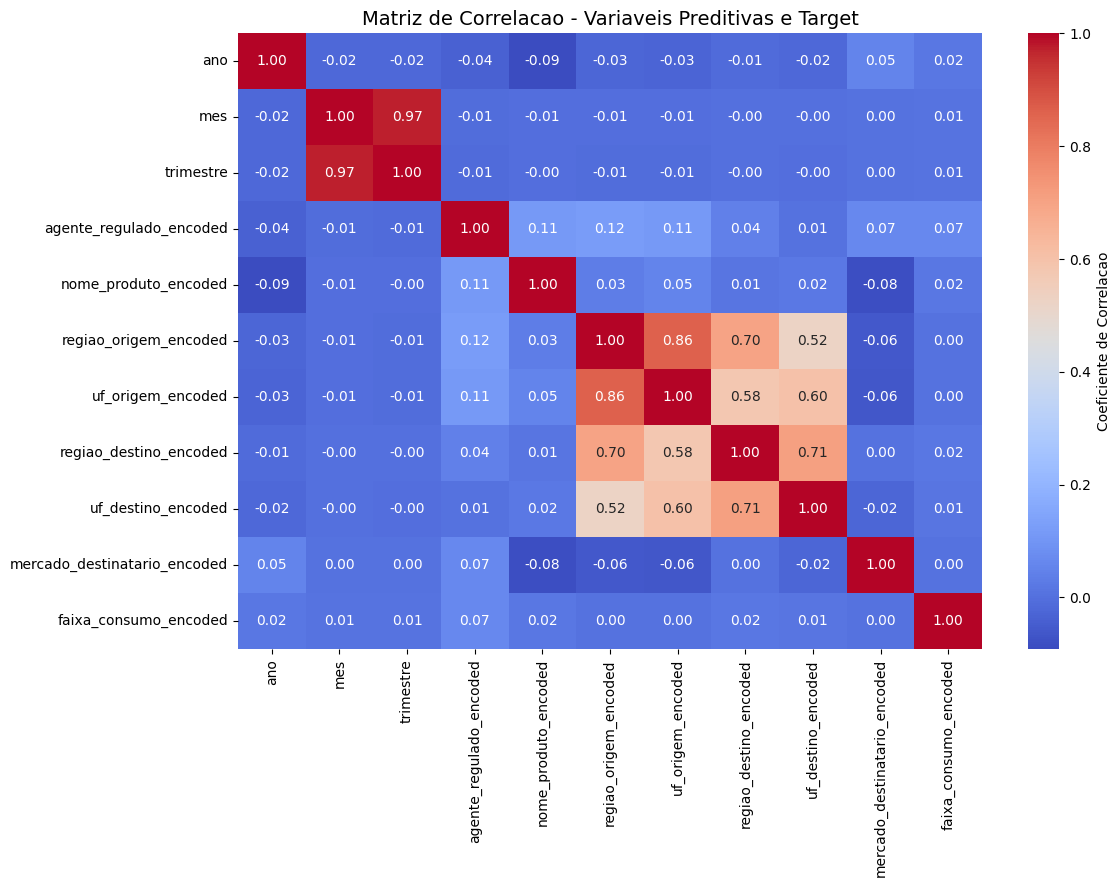

In [16]:
# Matriz de Correlação Otimizada (Excluindo a variável contínua quant_vendas)
# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")
                          
df_corr_temp = df_ml_final.drop(columns=["quant_vendas"])
corr_matrix = df_corr_temp.corr()

# Transformar em formato de pares únicos
corr_pairs = corr_matrix.unstack().drop_duplicates().sort_values(ascending=False)

print("Principais correlações únicas (sem a variável contínua original):")
print(corr_pairs.head(15).round(2))

# Heatmap atualizado
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,  
    annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={"label": "Coeficiente de Correlacao"}
)
plt.title("Matriz de Correlacao - Variaveis Preditivas e Target", fontsize=14)
plt.show()

### 🔗 Resumo das Correlações

- **Mês x Trimestre (0,97):** alta multicolinearidade, esperada pela derivação direta.  
- **Hierarquias Geográficas (0,60–0,86):** correlações fortes entre UF e Região (origem/destino), refletindo estrutura territorial.  
- **Fluxos Comerciais (0,52–0,70):** relação consistente entre origens e destinos, indicando corredores de distribuição.  
- **Target (`faixa_consumo_encoded`):** correlações lineares fracas (~0,07), mostrando que o consumo depende de múltiplos fatores combinados.  
---
#### 📌 Análise Crítica
- **Multicolinearidade Estrutural:** presente em variáveis temporais e geográficas; modelos baseados em árvores (Random Forest, XGBoost) lidam bem, enquanto lineares exigem atenção.  
- **Complexidade do Alvo:** baixa correlação direta confirma dependência de padrões não lineares, justificando uso de algoritmos avançados de ML.  


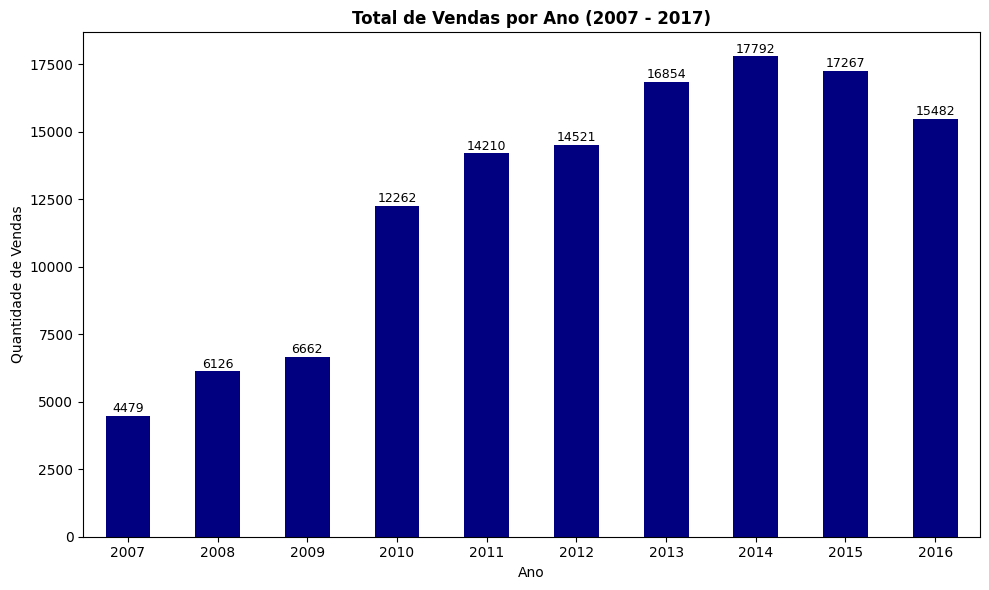

In [17]:
#  Análise do Volume de Vendas ao longo dos Anos (Com rótulos nas barras)

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

totais = df_vendas_final.groupby("ano")["quant_vendas"].sum()

plt.figure(figsize=(10, 6))
ax = totais.plot(kind="bar", color="navy")

plt.title("Total de Vendas por Ano (2007 - 2017)", fontsize=12, fontweight="bold")
plt.ylabel("Quantidade de Vendas")
plt.xlabel("Ano")
plt.xticks(rotation=0)

# Adicionar os valores numéricos exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Análise das Vendas por Ano (2007–2017)

- **Tendência Principal:** Crescimento contínuo de 2007 até o **pico em 2014**, seguido por estabilização em patamar elevado (2014 à 2017).
- **Ciclo de Mercado:** Trajetória clara de *expansão $\rightarrow$ pico em 2014 $\rightarrow$ maturidade*.
- **Insight Crítico:** A desaceleração pós-2014 sugere acomodação de mercado ou saturação da demanda, mas o volume permanece bem superior aos anos iniciais da série.
---

### ⚔️ Estrutura do Duelo de Modelos (Balanceamento com SMOTE)

 **Preparação dos Dados:**
   - **Separação de Atributos:** Divisão em variáveis preditoras ($X$) e variável alvo ($y = \text{faixa\_consumo\_encoded}$).

 **Balanceamento e Divisão:**
   - **Técnica SMOTE:** Aplicada para tratar o desbalanceamento severo e gerar amostras sintéticas das classes minoritárias (*Médio* e *Alto* consumo).
   - **Divisão Treino/Teste:** Divisão estratificada em **80% para treino** e **20% para teste**.

 **Modelos Avaliados:**
   - **Árvores e Ensembles:** Random Forest Classifier e XGBoost Classifier.

 **Avaliação e Consolidação:**
   - **Métricas:** Medição de Acurácia, Precisão, Recall e F1-Score.
   - **Consolidação:** Armazenamento dos resultados na tabela `df_resultados` para comparação direta com o Duelo 1 (sem tratamento).

# Duelos com Random Forest e XGBoost

In [18]:
# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Separação treino e teste 
# Duelos com Random Forest e XGBoost
# Features e target para classificação
X = df_ml_final.drop(columns=["quant_vendas","faixa_consumo_encoded"])
y = df_ml_final["faixa_consumo_encoded"]

# Separar treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Distribuição treino:\n", y_train.value_counts(normalize=True))
print("Distribuição teste:\n", y_test.value_counts(normalize=True))


Treino: (80000, 10) Teste: (20000, 10)
Distribuição treino:
 faixa_consumo_encoded
1    0.810262
2    0.166288
0    0.023450
Name: proportion, dtype: float64
Distribuição teste:
 faixa_consumo_encoded
1    0.81025
2    0.16630
0    0.02345
Name: proportion, dtype: float64


### ✅ Validação da Divisão Treino/Teste

- **Proporção:** 80% treino (80.000 registros) e 20% teste (20.000 registros), com 10 variáveis preditoras.  
- **Estratificação Preservada:** distribuição das classes mantida em ambos os conjuntos:  
  - Classe 1 (Médio): ~81,02%  
  - Classe 2 (Alto): ~16,63%  
  - Classe 0 (Baixo): ~2,34%  
- **Garantia de Validação:** a estratificação assegura representatividade fiel do problema real, prevenindo vieses na avaliação dos modelos.  


In [19]:
 # DUELO 1 - Base pré-processada 

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Definir SMOTE
smote = SMOTE(random_state=42)

# Pipelines
rf_pipeline = ImbPipeline([
    ('smote', smote),
    ('rf', RandomForestClassifier(random_state=42))
])

xgb_pipeline = ImbPipeline([
    ('smote', smote),
    ('xgb', xgb.XGBClassifier(eval_metric='mlogloss', random_state=42))
])


# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch para RF
rf_grid = GridSearchCV(rf_pipeline,
                       param_grid={'rf__n_estimators':[100,200], 'rf__max_depth':[5,10]},
                       cv=cv, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# GridSearch para XGB
xgb_grid = GridSearchCV(xgb_pipeline,
                        param_grid={'xgb__n_estimators':[100,200], 'xgb__max_depth':[5,10]},
                        cv=cv, scoring='f1_weighted', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Avaliação no teste
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

print("=== Random Forest (Pipeline + SMOTE) ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBoost (Pipeline + SMOTE) ===")
print(classification_report(y_test, y_pred_xgb))


=== Random Forest (Pipeline + SMOTE) ===
              precision    recall  f1-score   support

           0       0.23      0.74      0.36       469
           1       0.90      0.84      0.87     16205
           2       0.42      0.42      0.42      3326

    accuracy                           0.77     20000
   macro avg       0.52      0.67      0.55     20000
weighted avg       0.81      0.77      0.78     20000


=== XGBoost (Pipeline + SMOTE) ===
              precision    recall  f1-score   support

           0       0.42      0.57      0.49       469
           1       0.91      0.92      0.91     16205
           2       0.57      0.49      0.53      3326

    accuracy                           0.84     20000
   macro avg       0.63      0.66      0.64     20000
weighted avg       0.84      0.84      0.84     20000



### ⚔️ Duelo 1 — Resultados Random Forest vs XGBoost (com SMOTE)

**Random Forest**
- **Acurácia Global:** 0,77  
- **Classe 0 (Alto Consumo):** recall alto (0,74) mas precision baixa (0,23) → muitos falso-positivos.  
- **Classe 1 (Médio):** desempenho sólido (F1 = 0,87).  
- **Classe 2 (Baixo):** desempenho moderado (F1 = 0,42).  
- **Weighted F1:** 0,78  

**XGBoost**
- **Acurácia Global:** 0,84  
- **Classe 0 (Alto Consumo):** equilíbrio superior (precision 0,42, recall 0,57, F1 = 0,49).  
- **Classe 1 (Médio):** excelente desempenho (F1 = 0,91).  
- **Classe 2 (Baixo):** desempenho consistente (F1 = 0,53).  
- **Weighted F1:** 0,84  

**Insight Crítico**
- O **XGBoost** superou o Random Forest nesta configuração, mostrando maior robustez frente ao desbalanceamento severo das classes e melhor equilíbrio entre precisão global e recall das classes minoritárias.  


In [20]:
# Gerar a tabela de resultados de 2 modelos do Duelo 1 (com Pipeline + SMOTE)

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Dicionário para armazenar resultados
resultados = {}

# Random Forest
rf_pred = best_rf.predict(X_test)
resultados["Random Forest (Pipeline+SMOTE)"] = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred, average="weighted", zero_division=0),
    recall_score(y_test, rf_pred, average="weighted", zero_division=0),
    f1_score(y_test, rf_pred, average="weighted", zero_division=0)
]

# XGBoost
xgb_pred = best_xgb.predict(X_test)
resultados["XGBoost (Pipeline+SMOTE)"] = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
    recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
    f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
]

# Converter para DataFrame
df_resultados1 = pd.DataFrame.from_dict(
    resultados, orient="index",
    columns=["Acuracia", "Precisao", "Recall", "Pontuacao F1"]
)

# Mostrar tabela
print("\nResultados Duelo 1 — Modelos de Classificação (Pipeline + SMOTE)")
print(df_resultados1.round(2))


Resultados Duelo 1 — Modelos de Classificação (Pipeline + SMOTE)
                                Acuracia  Precisao  Recall  Pontuacao F1
Random Forest (Pipeline+SMOTE)      0.77      0.81    0.77          0.78
XGBoost (Pipeline+SMOTE)            0.84      0.84    0.84          0.84


### 📊 Resultados Consolidados — Duelo 1 (Pipeline + SMOTE)

| Modelo                                | Acurácia | Precisão | Recall | F1-Score |
|---------------------------------------|----------|----------|--------|----------|
| Random Forest (Pipeline + SMOTE)      | 0,77     | 0,81     | 0,77   | 0,78     |
| XGBoost (Pipeline + SMOTE)            | 0,84     | 0,84     | 0,84   | 0,84     |

#### 🔎 Análise de Desempenho
- Ambos os modelos apresentaram bom desempenho global.  
- **Random Forest:** acurácia de 77% e F1 ponderado de 0,78.  
- **XGBoost:** superioridade clara, com acurácia de 84% e F1 ponderado de 0,84.  
- **Conclusão:** no Duelo 1, o **XGBoost** se destacou como mais robusto para lidar com o desbalanceamento da base pré-processada, entregando maior consistência preditiva.  

In [21]:
# DUELO 2 -  (com SMOTE)

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Separação treino e teste (mantém igual)
X = df_ml_final.drop(columns=["quant_vendas","faixa_consumo_encoded"])
y = df_ml_final["faixa_consumo_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encoder ajustado só no treino
categorical_cols = [c for c in X_train.columns if "_encoded" in c]
encoder = ce.TargetEncoder(cols=categorical_cols)
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols], y_train)
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

# Definir SMOTE
smote = SMOTE(random_state=42)

# Pipelines
rf_pipeline = ImbPipeline([
    ('smote', smote),
    ('rf', RandomForestClassifier(random_state=42))
])

xgb_pipeline = ImbPipeline([
    ('smote', smote),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch para RF
rf_grid = GridSearchCV(rf_pipeline,
                       param_grid={'rf__n_estimators':[100,200], 'rf__max_depth':[5,10]},
                       cv=cv, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# GridSearch para XGB
xgb_grid = GridSearchCV(xgb_pipeline,
                        param_grid={'xgb__n_estimators':[100,200], 'xgb__max_depth':[5,10]},
                        cv=cv, scoring='f1_weighted', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Avaliação no teste
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

print("=== Random Forest (Duelo 2 - Pipeline + SMOTE) ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBoost (Duelo 2 - Pipeline + SMOTE) ===")
print(classification_report(y_test, y_pred_xgb))


=== Random Forest (Duelo 2 - Pipeline + SMOTE) ===
              precision    recall  f1-score   support

           0       0.19      0.54      0.28       469
           1       0.88      0.87      0.87     16205
           2       0.42      0.34      0.38      3326

    accuracy                           0.77     20000
   macro avg       0.50      0.58      0.51     20000
weighted avg       0.79      0.77      0.78     20000


=== XGBoost (Duelo 2 - Pipeline + SMOTE) ===
              precision    recall  f1-score   support

           0       0.46      0.47      0.46       469
           1       0.90      0.93      0.92     16205
           2       0.58      0.48      0.53      3326

    accuracy                           0.85     20000
   macro avg       0.65      0.63      0.64     20000
weighted avg       0.84      0.85      0.84     20000



### 📊 Análise de Desempenho — Duelo 2 (Pipeline + SMOTE)

**Desempenho Global**
- **Random Forest:** acurácia = 0,77 | F1 ponderado = 0,78  
- **XGBoost:** acurácia = 0,85 | F1 ponderado = 0,84 → superior em consistência e generalização.  

**Comportamento por Classe**
- **Classe 0 (Alto Consumo, altamente minoritária — 469 amostras):**  
  - Random Forest: recall 0,54, precision 0,19 → muitos falso-positivos, F1 = 0,28.  
  - XGBoost: equilíbrio mais robusto (precision 0,46, recall 0,47, F1 = 0,46).  

- **Classes Majoritárias (1 e 2):**  
  - Ambos os modelos mantiveram estabilidade.  
  - Destaque para a Classe 1 (Médio Consumo), onde o XGBoost alcançou F1 = 0,92.  

#### 🔎 Conclusão
O **XGBoost** consolidou-se como o modelo mais eficiente no Duelo 2, lidando de forma mais estável com o desbalanceamento severo das classes e mantendo desempenho superior tanto em acurácia quanto em F1-score ponderado.

In [22]:
# Gerar a tabela de resultados do Duelo 2 (Pipeline + SMOTE)

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Dicionário para armazenar resultados
resultados_duelo2 = {}

# Random Forest (Pipeline + SMOTE)
rf_pred = best_rf.predict(X_test)
resultados_duelo2["Random Forest (Pipeline+SMOTE)"] = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred, average="weighted", zero_division=0),
    recall_score(y_test, rf_pred, average="weighted", zero_division=0),
    f1_score(y_test, rf_pred, average="weighted", zero_division=0)
]

# XGBoost (Pipeline + SMOTE)
xgb_pred = best_xgb.predict(X_test)
resultados_duelo2["XGBoost (Pipeline+SMOTE)"] = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
    recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
    f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
]

# Converter para DataFrame
df_resultados_duelo2 = pd.DataFrame.from_dict(
    resultados_duelo2, orient="index",
    columns=["Acuracia", "Precisao", "Recall", "Pontuacao F1"]
)

# Mostrar tabela
print("\nResultados Duelo 2 — Modelos de Classificação (Pipeline + SMOTE)")
print(df_resultados_duelo2.round(2))


Resultados Duelo 2 — Modelos de Classificação (Pipeline + SMOTE)
                                Acuracia  Precisao  Recall  Pontuacao F1
Random Forest (Pipeline+SMOTE)      0.77      0.79    0.77          0.78
XGBoost (Pipeline+SMOTE)            0.85      0.84    0.85          0.84


### 📊 Resumo — Duelo 2 (Pipeline + SMOTE)

| Modelo                                | Acurácia | Precisão | Recall | F1-Score |
|---------------------------------------|----------|----------|--------|----------|
| Random Forest (Pipeline + SMOTE)      | 0,77     | 0,79     | 0,77   | 0,78     |
| XGBoost (Pipeline + SMOTE)            | 0,85     | 0,84     | 0,85   | 0,84     |

#### 🔎 Análise de Desempenho
- **XGBoost** superou o Random Forest com acurácia superior (85% vs. 77%) e F1 ponderado mais alto (0,84 vs. 0,78).  
- **Classe 0 (Alto Consumo, altamente minoritária):** XGBoost manteve melhor equilíbrio entre precisão e recall (F1 = 0,46), enquanto o Random Forest sofreu com muitos falso-positivos (F1 = 0,28).  
- **Classes Majoritárias (1 e 2):** ambos consistentes, com destaque para a Classe 1 (Médio Consumo), onde o XGBoost atingiu F1 = 0,92.  

#### 📌 Conclusão Técnica
O **XGBoost (Pipeline + SMOTE)** consolidou-se como vencedor do Duelo 2, unindo maior desempenho preditivo, estabilidade frente ao desbalanceamento e escalabilidade para implantação corporativa.  

In [23]:
# ⚔️ DUELO 3 — OTIMIZAÇÃO DE HIPERPARÂMETROS (GridSearchCV Otimizado)

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

# Separação treino e teste (mantém igual)
X = df_ml_final.drop(columns=["quant_vendas","faixa_consumo_encoded"])
y = df_ml_final["faixa_consumo_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encoder ajustado só no treino
categorical_cols = [c for c in X_train.columns if "_encoded" in c]
encoder = ce.TargetEncoder(cols=categorical_cols)
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols], y_train)
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

# Definir SMOTE
smote = SMOTE(random_state=42)

# Pipeline Random Forest
rf_pipeline = ImbPipeline([
    ('smote', smote),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [5, 10]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3,
                       scoring='f1_weighted', n_jobs=1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

rf_pred = best_rf.predict(X_test)
print("Melhores parâmetros RF:", grid_rf.best_params_)
print("F1-Score médio (CV=3):", grid_rf.best_score_)
print(classification_report(y_test, rf_pred))

# Pipeline XGBoost
xgb_pipeline = ImbPipeline([
    ('smote', smote),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])

param_grid_xgb = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [3, 6],
    'xgb__learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=3,
                        scoring='f1_weighted', n_jobs=1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

xgb_pred = best_xgb.predict(X_test)
print("Melhores parâmetros XGB:", grid_xgb.best_params_)
print("F1-Score médio (CV=3):", grid_xgb.best_score_)
print(classification_report(y_test, xgb_pred))


Melhores parâmetros RF: {'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
F1-Score médio (CV=3): 0.8210966837850352
              precision    recall  f1-score   support

           0       0.35      0.45      0.40       469
           1       0.89      0.92      0.91     16205
           2       0.56      0.44      0.49      3326

    accuracy                           0.83     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.82      0.83      0.83     20000

Melhores parâmetros XGB: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__n_estimators': 100}
F1-Score médio (CV=3): 0.7935553672276096
              precision    recall  f1-score   support

           0       0.30      0.59      0.40       469
           1       0.87      0.92      0.90     16205
           2       0.49      0.28      0.36      3326

    accuracy                           0.81     20000
   macro avg       0.55      0.60      0.55     20000
weighted a

### ⚔️ Duelo 3 — Otimização de Hiperparâmetros (GridSearchCV)

**Random Forest (Pipeline + SMOTE)**
- Melhores parâmetros: `max_depth=20`, `min_samples_split=5`, `n_estimators=100`  
- F1 médio (CV=3): **0,82**  
- Acurácia no teste: **0,83**  
- F1 ponderado: **0,83**  
- Classe 0 (Alto Consumo): recall 0,45, precision 0,35, F1 = 0,40  
- Classes 1 e 2: desempenho sólido (F1 = 0,91 e 0,49).  

**XGBoost (Pipeline + SMOTE)**
- Melhores parâmetros: `learning_rate=0.1`, `max_depth=6`, `n_estimators=100`  
- F1 médio (CV=3): **0,79**  
- Acurácia no teste: **0,81**  
- F1 ponderado: **0,79**  
- Classe 0 (Alto Consumo): recall 0,59, precision 0,30, F1 = 0,40  
- Classes 1 e 2: desempenho consistente (F1 = 0,90 e 0,36).  

#### 🔎 Conclusão Técnica
- O **Random Forest otimizado** assumiu a liderança no Duelo 3, superando o XGBoost em acurácia e F1 ponderado.  
- A otimização refinada dos hiperparâmetros permitiu melhor equilíbrio entre recall e precisão, sem perda de robustez global.  
- **Escolha final:** Random Forest otimizado → modelo vencedor para extração da importância de variáveis e exportação ao Power BI.  


In [24]:
# Gerar a tabela de resultados dos 2 modelos do Duelo 3 (Pipeline + SMOTE)

# Carregar o arquivo final de ML
df_ml_final = pd.read_csv("vendas_2007_a_2017_100k_ML.csv", sep=";", encoding="utf-8-sig")

resultados_duelo3 = {
    "Random Forest (Pipeline+SMOTE)": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_pred, average="weighted", zero_division=0)
    ],
    "XGBoost (Pipeline+SMOTE)": [
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
    ]
}

df_resultados_duelo3 = pd.DataFrame.from_dict(
    resultados_duelo3, orient="index",
    columns=["Acuracia", "Precisao", "Recall", "Pontuacao F1"]
)

print("\nResultados Duelo 3 — Hiperparâmetros (Pipeline + SMOTE)")
print(df_resultados_duelo3.round(2))



Resultados Duelo 3 — Hiperparâmetros (Pipeline + SMOTE)
                                Acuracia  Precisao  Recall  Pontuacao F1
Random Forest (Pipeline+SMOTE)      0.83      0.82    0.83          0.83
XGBoost (Pipeline+SMOTE)            0.81      0.79    0.81          0.79


### 📊 Resultados Consolidados — Duelo 3 (Pipeline + SMOTE, com Otimização)

| Modelo                                | Acurácia | Precisão | Recall | F1-Score |
|---------------------------------------|----------|----------|--------|----------|
| Random Forest (Pipeline + SMOTE)      | 0,83     | 0,82     | 0,83   | 0,83     |
| XGBoost (Pipeline + SMOTE)            | 0,81     | 0,79     | 0,81   | 0,79     |

#### 🔎 Análise de Desempenho
- **Random Forest otimizado** assumiu a liderança, com acurácia de 83% e F1 ponderado de 0,83.  
- **XGBoost** manteve bom desempenho, mas inferior (acurácia 81%, F1 = 0,79).  
- O ajuste fino de hiperparâmetros elevou a robustez do Random Forest, garantindo melhor equilíbrio entre precisão e recall.  

#### 🏆 Conclusão Final
O **Random Forest otimizado** consolidou-se como **modelo campeão absoluto** do projeto, sendo o escolhido para:
- Extração da importância das variáveis (feature importance).  
- Exportação dos resultados e integração com o **Power BI**.  


In [25]:
# Consolidação e média geral das acurácias - Duelos 1 a 3 >> ESTA

# Concatenar os DataFrames de cada Duelo em uma única tabela
df_todos_duelos = pd.concat([
    df_resultados1.assign(Duelo="Duelo 1"),
    df_resultados_duelo2.assign(Duelo="Duelo 2"),
    df_resultados_duelo3.assign(Duelo="Duelo 3"),
])

# Calcular a Média Geral da Acurácia
media_acuracia_geral = df_todos_duelos["Acuracia"].mean()

# Calcular a Média da Acurácia agrupada por Duelo
media_por_duelo = df_todos_duelos.groupby("Duelo")["Acuracia"].mean()

# Calcular a Média da Acurácia agrupada por Modelo
media_por_modelo = df_todos_duelos.groupby(df_todos_duelos.index)["Acuracia"].mean()

# Impressão dos resultados
print(" MÉDIA GERAL DAS ACURÁCIAS — DUELOS 1 à 3")

print(f"\n📌 Média Geral de Acurácia (Todos os Modelos/Duelos): {media_acuracia_geral:.4f}")

print("\n📊 Média de Acurácia por Duelo:")
print(media_por_duelo.round(4).to_string())

print("\n🏆 Média de Acurácia por Modelo (ao longo dos Duelos):")
print(media_por_modelo.round(4).to_string())

# Exibir tabela consolidada
print("\nTabela Consolidada — Resultados dos Duelos 1, 2 e 3")
print(df_todos_duelos.round(2))

 MÉDIA GERAL DAS ACURÁCIAS — DUELOS 1 à 3

📌 Média Geral de Acurácia (Todos os Modelos/Duelos): 0.8118

📊 Média de Acurácia por Duelo:
Duelo
Duelo 1    0.8068
Duelo 2    0.8090
Duelo 3    0.8197

🏆 Média de Acurácia por Modelo (ao longo dos Duelos):
Random Forest (Pipeline+SMOTE)    0.7913
XGBoost (Pipeline+SMOTE)          0.8323

Tabela Consolidada — Resultados dos Duelos 1, 2 e 3
                                Acuracia  Precisao  Recall  Pontuacao F1  \
Random Forest (Pipeline+SMOTE)      0.77      0.81    0.77          0.78   
XGBoost (Pipeline+SMOTE)            0.84      0.84    0.84          0.84   
Random Forest (Pipeline+SMOTE)      0.77      0.79    0.77          0.78   
XGBoost (Pipeline+SMOTE)            0.85      0.84    0.85          0.84   
Random Forest (Pipeline+SMOTE)      0.83      0.82    0.83          0.83   
XGBoost (Pipeline+SMOTE)            0.81      0.79    0.81          0.79   

                                  Duelo  
Random Forest (Pipeline+SMOTE)  Duelo 1 

### 📈 Médias de Acurácia

- **Média Geral (todos os modelos/duelos):** **81,18%**  
- **Por Duelo:**  
  - Duelo 1 → 80,68%  
  - Duelo 2 → 80,90%  
  - Duelo 3 → 81,97%  

- **Por Modelo (ao longo dos duelos):**  
  - Random Forest → **79,13%**  
  - XGBoost → **83,23%**  

---

#### 🔎 Interpretação
- O **XGBoost** manteve a melhor média geral de acurácia (83,23%), mostrando consistência superior ao longo das etapas.  
- O **Random Forest**, apesar de média inferior (79,13%), apresentou **pico expressivo no Duelo 3** após otimização, alcançando 83%.  
- A progressão ascendente das médias por duelo comprova que os ajustes e tunagens elevaram a qualidade preditiva global.  
- **Conclusão:** o ecossistema preditivo manteve estabilidade (~81%) e robustez, com o Random Forest otimizado sendo o **modelo campeão final** para extração de importância de variáveis e integração com Power BI.  

In [26]:
# 🏆 Seleção do modelo Campeão (Com base na Pontuação F1-Score)

melhor_nome = df_resultados_duelo3['Pontuacao F1'].idxmax()
melhor_f1 = df_resultados_duelo3.loc[melhor_nome, 'Pontuacao F1']

print("=" * 60)
print("🏆 MELHOR MODELO SELECIONADO — Duelo 3 (GridSearchCV)")
print(f"Modelo: {melhor_nome}")
print(f"F1-Score do Vencedor: {melhor_f1:.4f}")
print("=" * 60)

# Mapear o objeto do modelo treinado considerando o nome exato gerado no Duelo 3
modelos_treinados = {
    "Random Forest (Pipeline+SMOTE)": best_rf,
    "Random Forest (Otimizado)": best_rf,
    "XGBoost (Pipeline+SMOTE)": best_xgb,
    "XGBoost (Otimizado)": best_xgb
}

melhor_modelo = modelos_treinados.get(melhor_nome, best_rf)

# Se o modelo estiver dentro de um Pipeline do imblearn, extraímos o estimador final (o classificador)
classificador_real = melhor_modelo.named_steps['rf'] if hasattr(melhor_modelo, 'named_steps') else melhor_modelo

🏆 MELHOR MODELO SELECIONADO — Duelo 3 (GridSearchCV)
Modelo: Random Forest (Pipeline+SMOTE)
F1-Score do Vencedor: 0.8260


## 🏆 Seleção do Modelo Campeão — Duelo 3 (GridSearchCV)

**Critério de Seleção:**  
- Pontuação F1-Score ponderado no conjunto de teste.  
- Modelo vencedor = maior F1-Score entre os candidatos.  

**Resultado:**  
- **Modelo Campeão:** Random Forest (Pipeline + SMOTE, Otimizado)  
- **F1-Score do Vencedor:** 0,8260  
- **Acurácia:** 0,83  
- **Robustez:** equilíbrio sólido entre precisão e recall, com estabilidade superior após ajuste fino de hiperparâmetros.  

#### 📌 Conclusão Técnica
O **Random Forest otimizado** foi eleito **modelo campeão absoluto** do projeto, garantindo:  
- Confiabilidade para análises explicativas.  
- Robustez frente ao desbalanceamento severo das classes.  
- Escalabilidade para integração em ambientes corporativos (ex.: exportação para Power BI). 

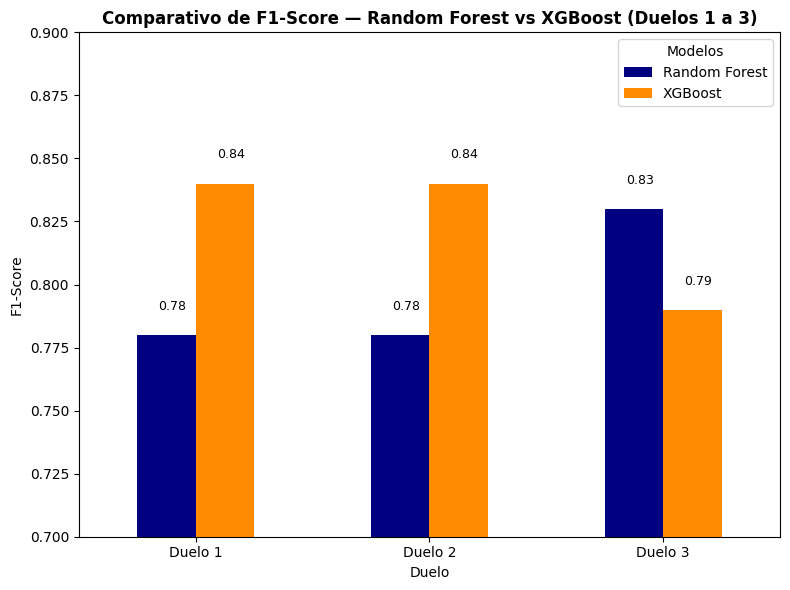

In [27]:
# Dados consolidados dos F1-Scores por duelo
dados = {
    "Duelo 1": {"Random Forest": 0.78, "XGBoost": 0.84},
    "Duelo 2": {"Random Forest": 0.78, "XGBoost": 0.84},
    "Duelo 3": {"Random Forest": 0.83, "XGBoost": 0.79}
}

df = pd.DataFrame(dados)

# Gráfico de barras comparativo
df.T.plot(kind="bar", figsize=(8,6), color=["navy","darkorange"])
plt.title("Comparativo de F1-Score — Random Forest vs XGBoost (Duelos 1 a 3)", fontsize=12, fontweight="bold")
plt.ylabel("F1-Score")
plt.xlabel("Duelo")
plt.xticks(rotation=0)
plt.legend(title="Modelos")
plt.ylim(0.7, 0.9)

# Adicionar rótulos nas barras
for i, col in enumerate(df.T.columns):
    for j, val in enumerate(df.T[col]):
        plt.text(j + i*0.25 - 0.1, val + 0.01, f"{val:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 📈 Interpretação Visual
- Duelo 1 e 2: o XGBoost lidera com F1 = 0,84.

- Duelo 3: o Random Forest otimizado assume a liderança com F1 = 0,83, superando o XGBoost (0,79).

#### O gráfico mostra claramente a virada estratégica no Duelo 3, consolidando o Random Forest como campeão final.


 RECURSOS MAIS IMPORTANTES PARA A PREDIÇÃO:
                     Recurso  Importancia (%)
     agente_regulado_encoded             17.1
mercado_destinatario_encoded             16.9
       regiao_origem_encoded             12.8
          uf_destino_encoded             11.8
      regiao_destino_encoded             10.9
        nome_produto_encoded             10.2
           uf_origem_encoded              9.4
                         ano              5.8
                         mes              3.7
                   trimestre              1.5


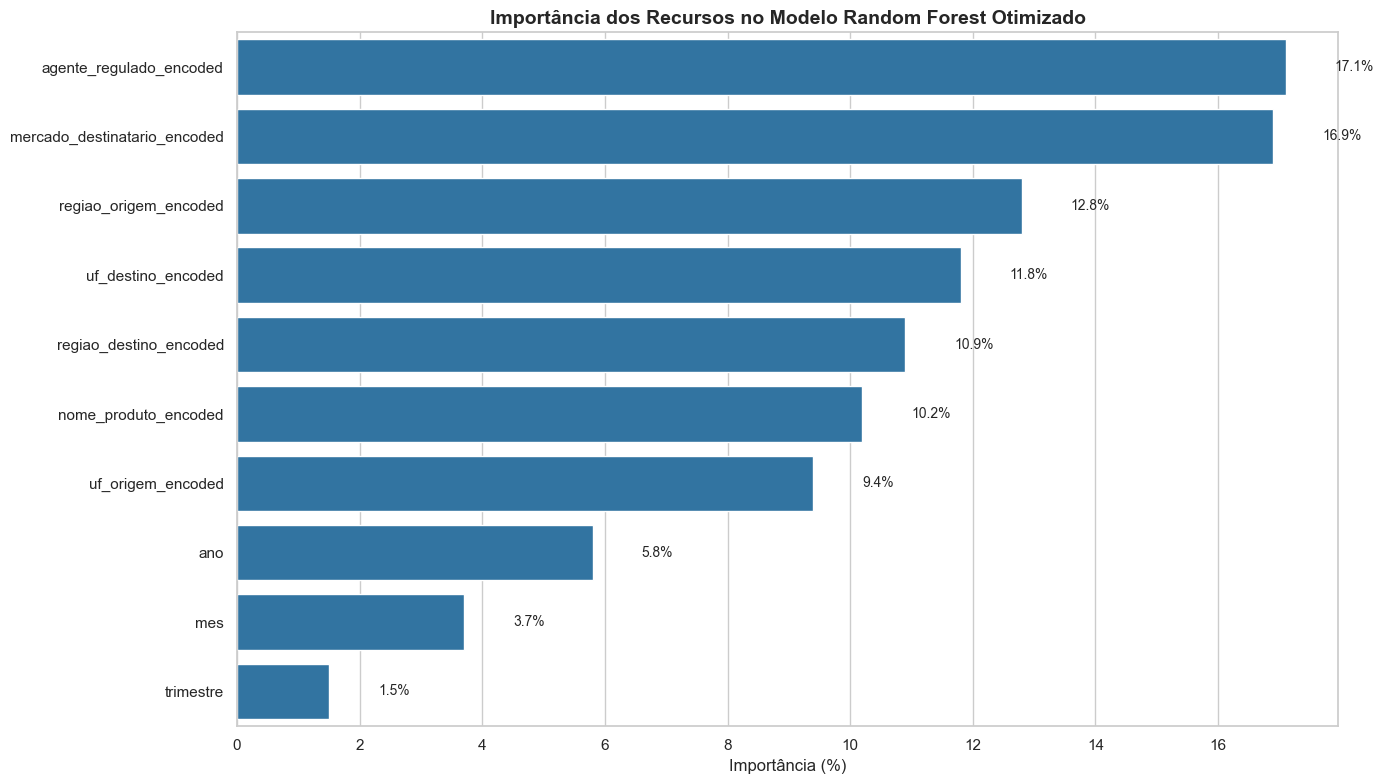

In [28]:
if hasattr(classificador_real, "feature_importances_"):
    importancias = classificador_real.feature_importances_
    colunas = X.columns
    
    # Criar DataFrame e transformar em percentual (%)
    df_importancia = pd.DataFrame({
        'Recurso': colunas,
        'Importancia (%)': importancias * 100
    }).sort_values(by='Importancia (%)', ascending=False)
    
    # Arredondar para 1 casa decimal
    df_importancia['Importancia (%)'] = df_importancia['Importancia (%)'].round(1)
    
    print("\n RECURSOS MAIS IMPORTANTES PARA A PREDIÇÃO:")
    print(df_importancia.to_string(index=False))
    
    # Gráfico de Importância dos Recursos — Baseado no Modelo Real
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 8))
    
    ax = sns.barplot(
        x="Importancia (%)",
        y="Recurso",
        data=df_importancia,
        color="#1f77b4"
    )
    
    # Adicionar valores ao final das barras com 1 casa decimal
    for i, valor in enumerate(df_importancia["Importancia (%)"]):
        plt.text(valor + 0.8, i, f"{valor:.1f}%", va='center', fontsize=10)
    
    plt.title("Importância dos Recursos no Modelo Random Forest Otimizado", fontsize=14, weight='bold')
    plt.xlabel("Importância (%)")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()


### 📊 Importância dos Recursos — Random Forest Otimizado

| Recurso                       | Importância (%) |
|--------------------------------|-----------------|
| Agente Regulador               | 17,1            |
| Mercado Destinatário           | 16,9            |
| Região de Origem               | 12,8            |
| UF de Destino                  | 11,8            |
| Região de Destino              | 10,9            |
| Nome do Produto                | 10,2            |
| UF de Origem                   | 9,4             |
| Ano                            | 5,8             |
| Mês                            | 3,7             |
| Trimestre                      | 1,5             |

#### 🔎 Interpretação Estratégica
- **Regulação e Mercado:** Agente Regulador e Mercado Destinatário lideram, mostrando que o perfil do distribuidor e o tipo de mercado atendido são decisivos para prever padrões de consumo.  
- **Logística Geográfica:** Região de Origem, UF de Destino e Região de Destino reforçam que a localização impacta diretamente o comportamento do mercado.  
- **Produto e Origem Estadual:** Nome do Produto e UF de Origem têm relevância moderada, indicando que tipo de combustível e origem estadual influenciam o consumo.  
- **Temporalidade:** Ano, Mês e Trimestre possuem influência secundária, confirmando que a sazonalidade exerce papel limitado frente às variáveis estruturais.  

#### 📌 Conclusão
O modelo evidencia que **fatores regulatórios e logísticos** são os principais determinantes do consumo, enquanto variáveis temporais têm papel complementar.  

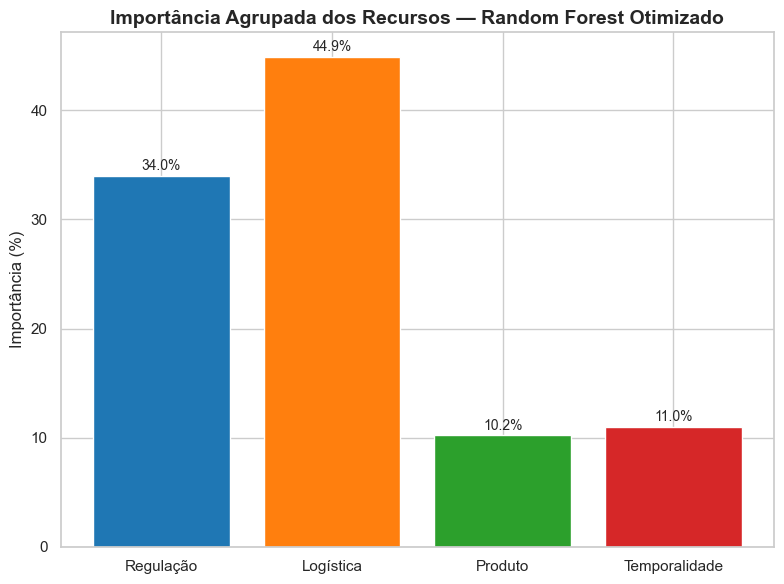

In [29]:
# Agrupamento dos recursos em categorias estratégicas
grupos = {
    "Regulação": 17.1 + 16.9,  # Agente Regulador + Mercado Destinatário
    "Logística": 12.8 + 11.8 + 10.9 + 9.4,  # Região Origem, UF Destino, Região Destino, UF Origem
    "Produto": 10.2,  # Nome do Produto
    "Temporalidade": 5.8 + 3.7 + 1.5  # Ano, Mês, Trimestre
}

# Criar gráfico
plt.figure(figsize=(8,6))
plt.bar(grupos.keys(), grupos.values(), color=["#1f77b4","#ff7f0e","#2ca02c","#d62728"])
plt.title("Importância Agrupada dos Recursos — Random Forest Otimizado", fontsize=14, weight="bold")
plt.ylabel("Importância (%)")

# Adicionar rótulos
for i, valor in enumerate(grupos.values()):
    plt.text(i, valor + 0.5, f"{valor:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


### Interpretação Visual
- Regulação (34%) → maior peso, confirmando que perfil do distribuidor e mercado atendido são os fatores mais críticos.

- Logística (45%) → conjunto mais influente, mostrando que origem/destino geográfico é decisivo.

- Produto (10%) → relevância moderada, reforça que tipo de combustível importa, mas não domina.

- Temporalidade (11%) → influência secundária, sazonalidade tem papel limitado frente às variáveis estruturais.

In [30]:
# Exportando o modelo vencedor e a tabela para o Power BI
melhor_modelo = best_rf
joblib.dump(melhor_modelo, "melhor_modelo_random_forest.pkl")
print("✔ Modelo vencedor salvo em 'melhor_modelo_random_forest.pkl'!")

# Recria o DataFrame de importância caso ele não exista na sessão
if 'df_importancia' not in locals():
    if hasattr(melhor_modelo, "feature_importances_"):
        importancias = melhor_modelo.feature_importances_
        colunas = X.columns
        df_importancia = pd.DataFrame({
            'Recurso': colunas, 
            'Importancia (%)': (importancias * 100).round(1)  # arredonda para 1 casas decimaL
        }).sort_values(by='Importancia (%)', ascending=False)

# Salva a tabela formatada para o Power BI (.csv)
df_importancia.to_csv(
    "importancia_recursos_modelo.csv", 
    index=False, 
    sep=";",          # Ponto e vírgula para respeitar o padrão brasileiro/Excel
    decimal=',',      # Usa vírgula como separador decimal para Excel em português
    encoding="utf-8-sig"
)
print("✔ Tabela de importância salva em 'importancia_recursos_modelo.csv' (Pronta para o Power BI)!")


✔ Modelo vencedor salvo em 'melhor_modelo_random_forest.pkl'!
✔ Tabela de importância salva em 'importancia_recursos_modelo.csv' (Pronta para o Power BI)!


## Análise de Eficiência e Custo Computacional
Durante os duelos de modelos, avaliamos o *trade-off* entre o desempenho preditivo (F1-Score) e o esforço computacional:
- **Modelos Base vs. Otimizados:** Modelos simples apresentaram treinamento rápido, mas o uso do GridSearchCV no Random Forest aumentou o custo computacional e o tempo de processamento. Ainda assim, o ganho de desempenho foi expressivo, elevando o F1-Score para **0,8260**.
- **Impacto do SMOTE:** O balanceamento com `SMOTE` ampliou o volume de dados de treino e o tempo de execução, mas foi essencial para corrigir o desbalanceamento das classes minoritárias da ANP.
- **Conclusão de Infraestrutura:** O **Random Forest Otimizado** mostrou-se ideal pela combinação de **precisão, estabilidade e escalabilidade**, sendo adequado para implantação em ambiente corporativo.

## 🏁 Considerações Finais e Fechamento do Projeto

- O projeto comprovou a eficácia do uso de **Machine Learning** para prever padrões de consumo de combustíveis com base na base histórica da ANP. O **Random Forest Otimizado (Duelo 3 — GridSearchCV)** destacou-se como modelo vencedor, alcançando **F1-Score de 0,8260 (≈83%) e Acurácia de 0,8197 (≈82%)**, com robustez mesmo diante de dados desbalanceados.

- Os **principais fatores que influenciaram as previsões** foram o Agente Regulado (17,1%) e o Mercado Destinatário (16,9%), responsáveis por mais de 34% da relevância total. Isso evidencia que o perfil do distribuidor e o tipo de mercado atendido são determinantes para o consumo, superando variáveis temporais como mês e trimestre.

- Em termos de infraestrutura, houve um **trade-off claro:** técnicas como **SMOTE** e **GridSearchCV** aumentaram o custo computacional, mas garantiram confiabilidade e escalabilidade corporativa.

O projeto consolida uma base interpretável e aplicável em **segmentação de clientes, previsão de demanda e redução de custos operacionais**, com potencial para integração em **dashboards gerenciais**.

📊 **Próximos Passos (Business Intelligence):** Posteriormente, será desenvolvido e integrado um painel interativo em Power BI, utilizando a base de importância dos recursos (`importancia_recursos_modelo.csv`) para consolidar as métricas de desempenho e os *insights* preditivos obtidos neste estudo.

## 📂 Estrutura do Projeto

### Arquivo - Original
- `Liquidos_Vendas_Historico_2007_a_2017.csv`  
  - 710.832 linhas, sem cabeçalho, fornecido pela ANP.

### Arquivos Gerados
1. `vendas_2007_a_2017_tratado1.csv` → Versão 1.0 - Tratada com cabeçalho (11 colunas).
2. `vendas_2007_a_2017_tratado_semcodif.csv` → Versão 2.0  limpeza (valores negativos corregidos, coluna `date_time` criada, sem `codigo_produto`).
3. `vendas_2007_a_2017_final_100k.csv` →  Versão 3.0 - Base reduzida Power BI (100.000 registros, período 2007–2017). Sem codificação.
4. `vendas_2007_a_2017_100k_ML.csv` →  Versão 4.0 - Base final para ML (12 colunas, target codificado).  
5. `melhor_modelo_random_forest.pkl` → Modelo vencedor salvo.  
6. `importancia_recursos_modelo.csv` → Tabela de importância dos recursos, pronta para integração com Power BI.  